# Phase 4 - K-Means Coreset Selection


---

### Research question
Phases 2 and 3 both selected images **at random within each class**. Phase 3 fixed only *how many*
images per class. Phase 4 is the first phase that decides *which* images, using the geometry of a
learned feature space.

Because Phase 4 enforces **the same per-class quota as Phase 3**, the difference

$$\Delta = \text{Phase 4} - \text{Phase 3}$$

isolates the effect of **intelligent within-class selection**, with the class-balance effect already
subtracted out. That subtraction is the entire experimental design.

### Method
Following the coreset / k-centers framing of **Coleman et al. 2020 (Selection via Proxy)** -
[arxiv.org/abs/1906.11829](https://arxiv.org/abs/1906.11829) - a small subset that *covers* the
feature space should train a model nearly as well as the full set, because discarded points lie near
a kept point and therefore add little new information. K-means is the standard cheap approximation
to that coverage objective.

1. Extract 256-d penultimate-layer embeddings using the **locked Phase 1 checkpoints** (frozen, eval mode).
2. Run K-means **per class**, with `k` = the Phase 3 per-class quota.
3. From each cluster, keep the real image **nearest that cluster's centroid**.

### Pre-committed hypothesis
*Stated before any Phase 4 result was seen.*

K-means coreset selection should meaningfully close the CIFAR-10 gap in the 1–5% range, because it
actively selects representative rather than redundant examples. If the gap does **not** close, that
is itself a real finding: it would indicate that coverage/representativeness is not the missing
ingredient, motivating Phase 5's hard-example framing instead.

### Fixed constants (unchanged from Phases 1–3)
Architecture, optimiser, scheduler, seeds, subset sizes, epochs, normalisation and augmentation are
**identical** to all previous phases. Only `sample_indices()` changes.


## Section 1- Imports & Configuration

`SEEDS`, `SUBSET_FRACS`, `BATCH_SIZE`, `NUM_WORKERS` and `EPOCHS` are copied verbatim from Phase 2.
Changing any of them would break comparability with the locked phases.

Paths are **auto-discovered** rather than hardcoded. Kaggle mounts inputs at a location that depends
on how each dataset was attached, so a hardcoded path silently breaks whenever the notebook is
re-imported or a session is recreated.


In [9]:
# ── Standard library ───────────────────────────────────────────
import os, json, random, time, hashlib, itertools, glob, shutil

# ── Numerical / ML ─────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

# ── Metrics, clustering, statistics, plotting ──────────────────
from sklearn.metrics import f1_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from scipy.stats import spearmanr, ttest_rel
import matplotlib.pyplot as plt

# ── Fixed constants — never change across phases ───────────────
SEEDS         = [42, 123, 456, 789, 1011]
SUBSET_FRACS  = [0.002, 0.005, 0.01, 0.02, 0.05]
SUBSET_LABELS = ['0.2%', '0.5%', '1%', '2%', '5%']
BATCH_SIZE    = 128
NUM_WORKERS   = 2
EPOCHS        = {'MNIST': 20, 'CIFAR10': 30}

# ── Output paths ───────────────────────────────────────────────
DATA_DIR       = '/kaggle/working/data'
CACHE_DIR      = '/kaggle/working/phase4_cache'      # embeddings + selected indices
CHECKPOINT_DIR = '/kaggle/working/checkpoints'       # Phase 4 models trained by this notebook
RESULTS_DIR    = '/kaggle/working/results'
FIGURES_DIR    = '/kaggle/working/figures'
for d in (DATA_DIR, CACHE_DIR, CHECKPOINT_DIR, RESULTS_DIR, FIGURES_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Auto-discover the Phase 1 checkpoints (read-only inputs) ───
_ckpt_hits = glob.glob('/kaggle/input/**/baseline_*_seed*_model.pth', recursive=True)
if not _ckpt_hits:
    print('Attached inputs:')
    for _d in (sorted(os.listdir('/kaggle/input')) if os.path.exists('/kaggle/input') else []):
        print('   /kaggle/input/' + _d)
    raise FileNotFoundError(
        'Phase 1 checkpoints not found. Sidebar -> Add Input -> Notebooks -> '
        'phase1-baseline-final')
CHECKPOINT_DIR_P1 = os.path.dirname(_ckpt_hits[0])

# ── Class names ────────────────────────────────────────────────
CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']
MNIST_CLASSES = [str(i) for i in range(10)]
CLASS_NAMES   = {'mnist': MNIST_CLASSES, 'cifar': CIFAR_CLASSES}

# ── Locked reference values from Phases 1-3 ────────────────────
# Comparison only. The source phases are never re-run and never modified.
P1 = {'MNIST':   {'top1': 98.98, 'std': 0.43},
      'CIFAR10': {'top1': 80.93, 'std': 0.33}}

P1_PER_CLASS_F1 = {
    'cifar': {'airplane': 0.8102, 'automobile': 0.9055, 'bird': 0.7262, 'cat': 0.6465,
              'deer': 0.7908, 'dog': 0.7386, 'frog': 0.8508, 'horse': 0.8468,
              'ship': 0.8903, 'truck': 0.8786},
    'mnist': {'0': 0.9926, '1': 0.9947, '2': 0.9918, '3': 0.9924, '4': 0.9905,
              '5': 0.9916, '6': 0.9887, '7': 0.9826, '8': 0.9915, '9': 0.9818},
}

P2_TOP1 = {'CIFAR10': [23.29, 33.12, 40.08, 48.00, 58.05],
           'MNIST':   [24.31, 82.03, 94.54, 95.68, 96.87]}
# CORRECTED 2026-07-22 from phase3_results.json (authoritative).
# MNIST values were previously 25.67/90.42/93.98/95.10/96.12 — wrong. CIFAR unchanged.
P3_TOP1 = {'CIFAR10': [23.33, 33.03, 40.50, 50.28, 57.00],
           'MNIST':   [25.74, 90.40, 94.23, 95.38, 96.16]}

# ── Canonical class ordering for EVERY categorical axis in this phase ──
# Supervisor feedback: categorical axes must run low -> high, and ONE ordering must be
# used across all figures so a reader never re-learns the order between plots.
# Anchored on Phase 1 per-class F1 ascending (hardest -> easiest) because that ordering
# is derived from Phase 1 and can therefore be reused identically in Phases 1-5.
# It correlates at Spearman rho = -0.96 with the intra/inter ratio, so figures keyed on
# either quantity still read as a clean gradient.
CLASS_ORDER = {k: sorted(CLASS_NAMES[k], key=lambda c: P1_PER_CLASS_F1[k][c])
               for k in ('cifar', 'mnist')}
CLASS_ORDER_IDX = {k: [CLASS_NAMES[k].index(c) for c in CLASS_ORDER[k]]
                   for k in ('cifar', 'mnist')}

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Phase 1 checkpoints: {CHECKPOINT_DIR_P1}')
print(f'  found {len(_ckpt_hits)} checkpoint files')

Device: cuda
GPU: Tesla T4
Phase 1 checkpoints: /kaggle/input/notebooks/nareshgudipalli/phase1-baseline-final
  found 10 checkpoint files


## Section 2 - Staging the Datasets

The Phase 1 notebook output already contains the extracted MNIST and CIFAR-10 files. Symlinking them
into `DATA_DIR` means torchvision finds them and skips its download, which on Kaggle runs at roughly
40 kB/s and takes over an hour for CIFAR-10.

This is safe and changes nothing scientifically: torchvision verifies every file's MD5 against
hardcoded reference hashes, so if the data were not bit-identical to the official archive the check
would fail and it would download the real thing anyway. The failure mode is *slow*, never *wrong*.


In [10]:
def stage_dataset(pattern: str, dest_name: str, label: str):
    """Symlink an already-extracted dataset from any attached input into DATA_DIR.

    Symlink rather than copy: instant, and torchvision only ever reads these files.
    """
    dest = os.path.join(DATA_DIR, dest_name)
    if os.path.exists(dest):
        print(f'{label}: already staged.')
        return
    hits = glob.glob(pattern, recursive=True)
    if hits:
        os.symlink(hits[0], dest)
        print(f'{label}: staged from {hits[0]}')
    else:
        print(f'{label}: not found in attached inputs — torchvision will download it.')


stage_dataset('/kaggle/input/**/cifar-10-batches-py', 'cifar-10-batches-py', 'CIFAR-10')
stage_dataset('/kaggle/input/**/MNIST',               'MNIST',               'MNIST')

CIFAR-10: already staged.
MNIST: already staged.


## Section 3 — Seeding Utilities

Copied **verbatim** from Phase 2. `set_seed` fixes the main process; `seed_worker` fixes each
DataLoader worker subprocess (without it, workers take OS-random seeds and reproducibility breaks
whenever `num_workers > 0`). `cudnn.deterministic = True` forces deterministic CUDA kernels;
`benchmark = False` stops CUDA auto-selecting algorithms that vary run to run.


In [11]:
def set_seed(seed: int):
    """Fix all random sources in the main process."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    """Called once per DataLoader worker at startup. Keeps workers deterministic.
    torch.initial_seed() returns the seed PyTorch assigned this worker;
    we propagate it to NumPy and Python random so all three are in sync.
    """
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Section 4 - Transforms & Datasets

`get_transforms` and `get_datasets` are copied **verbatim** from Phase 2. CIFAR-10 keeps
`RandomHorizontalFlip` + `RandomCrop(32, padding=4)`. This augmentation is a known confound for the
subset phases (it effectively enlarges tiny subsets), but it is applied **identically in every
phase**, so it cannot explain any between-phase difference.

Two Phase 4 additions:

- **`get_eval_trainset`** — the training split with the **evaluation transform**: normalise only, no
  flip, no crop. Used for embedding extraction. This is required, not cosmetic: with augmentation
  active, the same image would produce a different 256-d vector on every pass and K-means would be
  irreproducible.
- **`get_raw_dataset`** — `ToTensor()` only, no normalisation. Used purely for plotting selected
  images, so figures show true colours.


In [12]:
def get_transforms(dataset_name: str, train: bool):
    """Return the correct transform pipeline for each dataset and split."""
    if dataset_name == 'MNIST':
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
    else:  # CIFAR10
        if train:
            return transforms.Compose([
                transforms.RandomHorizontalFlip(),      # flip with p=0.5
                transforms.RandomCrop(32, padding=4),   # pad 4px each side, then crop to 32
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])
        else:
            return transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])


def get_datasets(dataset_name: str):
    """Download and return full train + test datasets with correct transforms."""
    if dataset_name == 'MNIST':
        train_ds = torchvision.datasets.MNIST(
            DATA_DIR, train=True,  download=True, transform=get_transforms('MNIST', True))
        test_ds  = torchvision.datasets.MNIST(
            DATA_DIR, train=False, download=True, transform=get_transforms('MNIST', False))
    else:
        train_ds = torchvision.datasets.CIFAR10(
            DATA_DIR, train=True,  download=True, transform=get_transforms('CIFAR10', True))
        test_ds  = torchvision.datasets.CIFAR10(
            DATA_DIR, train=False, download=True, transform=get_transforms('CIFAR10', False))
    return train_ds, test_ds


# ── Phase 4 additions ──────────────────────────────────────────
DS_KEY  = {'MNIST': 'mnist', 'CIFAR10': 'cifar'}   # long name -> short key
DS_LONG = {'mnist': 'MNIST', 'cifar': 'CIFAR10'}   # short key -> long name


def get_eval_trainset(key: str):
    """TRAIN split with the EVAL transform (normalise only, no flip/crop).

    Used ONLY for embedding extraction. Augmentation here would make the 256-d
    embedding of an image change on every pass, destroying K-means reproducibility.
    """
    name = DS_LONG[key]
    tf   = get_transforms(name, train=False)       # eval transform on the train split
    if name == 'MNIST':
        return torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=tf)
    return torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf)


def get_raw_dataset(key: str):
    """TRAIN split with ToTensor() only — no normalisation, no augmentation.
    Used solely for plotting, so selected images display in true colour."""
    name = DS_LONG[key]
    tf   = transforms.ToTensor()
    if name == 'MNIST':
        return torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=tf)
    return torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf)

## Section 5 - Model Architecture

Copied **verbatim** from Phase 2, with one addition: `forward_features()`.

The layer names (`block1`, `block2`, `block3`, `classifier`) and the `classifier` indices are not a
stylistic choice — they must match the saved Phase 1 `state_dict` exactly, or the checkpoints will
not load. Verified against `baseline_cifar10_seed42_model.pth`: 25 keys, with
`classifier.1.weight` of shape `(256, 512)` and `classifier.4.weight` of shape `(10, 256)`.

`forward_features()` returns the **256-d penultimate embedding** — the output of `classifier[2]`
(the ReLU), immediately before Dropout and the final `Linear(256, 10)`. This is the vector K-means
operates on. It adds no parameters and does not alter `forward()`.

The parameter-count assertion is the proof that the reconstruction is correct: matching keys under
`strict=True` **and** matching parameter counts leaves no room for a silent mismatch.


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super().__init__()
        # Block 1: in_channels -> 32, spatial /2
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 2: 32 -> 64, spatial /2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 3: 64 -> 128, spatial /2
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Adaptive pool -> fixed 2x2 output regardless of input spatial size
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        # Classifier: 128*2*2=512 -> 256 -> 10
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # [0] no parameters
            nn.Linear(128 * 2 * 2, 256),   # [1] 512 -> 256   (checkpoint key classifier.1)
            nn.ReLU(),                     # [2] no parameters  <-- 256-d embedding taken here
            nn.Dropout(0.5),               # [3] no parameters; identity under model.eval()
            nn.Linear(256, num_classes)    # [4] raw logits, no softmax (key classifier.4)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        return self.classifier(x)

    def forward_features(self, x):
        """PHASE 4 ADDITION — return the 256-d penultimate embedding.

        Runs the convolutional trunk, then only the first three classifier layers
        (Flatten -> Linear(512,256) -> ReLU), stopping before Dropout and the final
        Linear. Adds no parameters and leaves forward() untouched.
        """
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        for layer in self.classifier[:3]:   # [0] Flatten, [1] Linear(512,256), [2] ReLU used for embedding.
            x = layer(x)  
        return x


# Parameter counts must match the loaded Phase 1 checkpoints exactly.
for ch, expect in [(1, 227_018), (3, 227_594)]:
    n = sum(p.numel() for p in SimpleCNN(in_channels=ch).parameters())
    assert n == expect, f'in_channels={ch}: got {n:,} params, expected {expect:,}'
    print(f'in_channels={ch}: {n:,} parameters  OK')

in_channels=1: 227,018 parameters  OK
in_channels=3: 227,594 parameters  OK


## Section 6 - Embedding Extraction from Locked Phase 1 Checkpoints

### Why embeddings rather than raw pixels
Euclidean distance between raw CIFAR images is close to meaningless: two photographs of the same cat
under different lighting are far apart in pixel space, while a cat and a dog on similar backgrounds
are close. A trained CNN's penultimate layer is optimised precisely to make same-class inputs cluster
and different-class inputs separate, so K-means in that space groups images by *semantic* similarity
— which is what "redundant example" must mean for the coreset argument to hold.

### One checkpoint per seed
Phase 4 run with seeds uses embeddings extracted from `baseline_*_seed{s}_model.pth`.

This matters for how the error bars should be read. In Phases 2 and 3, changing the seed produced a
completely different subset. If Phase 4 used a single fixed feature space, the seed would perturb
only K-means initialisation, and Phase 4's ±std would measure something different *in kind* from
Phase 2/3's. Using per-seed checkpoints keeps the variance estimates comparable across phases, and
matches Phase 5, which reuses all five checkpoints.

### Guarantees enforced below
- `strict=True` on `load_state_dict` - a silent partial load is impossible.
- `model.eval()` - BatchNorm uses running statistics, Dropout becomes the identity.
- `torch.no_grad()` - the Phase 1 models are read-only and are never updated.
- `shuffle=False` - row *i* of the embedding matrix corresponds to dataset index *i*.


In [14]:
# Phase 1 checkpoints: read-only inputs.
CKPT_ALL = {
    'mnist': {s: f'{CHECKPOINT_DIR_P1}/baseline_mnist_seed{s}_model.pth'   for s in SEEDS},
    'cifar': {s: f'{CHECKPOINT_DIR_P1}/baseline_cifar10_seed{s}_model.pth' for s in SEEDS},
}
missing = [p for d in CKPT_ALL.values() for p in d.values() if not os.path.exists(p)]
assert not missing, f'Missing Phase 1 checkpoints: {missing}'
print(f'All {len(SEEDS) * 2} Phase 1 checkpoints found.')


def load_phase1_model(key: str, seed: int):
    """Load one frozen Phase 1 model. strict=True makes a partial load impossible:
    if the architecture above did not match the saved state_dict, this raises rather
    than silently loading a half-random network."""
    model = SimpleCNN(in_channels=1 if key == 'mnist' else 3, num_classes=10)
    obj   = torch.load(CKPT_ALL[key][seed], map_location='cpu')
    sd    = obj.get('model_state_dict', obj) if isinstance(obj, dict) else obj
    model.load_state_dict(sd, strict=True)
    model.eval().to(DEVICE)
    return model


def extract_embeddings(key: str, seed: int, force: bool = False):
    """One forward pass over the full training split with the frozen seed-`seed` model.

    Returns (embeddings [N, 256] float32, labels [N] int64) and caches both to disk.
    shuffle=False keeps row i aligned with dataset index i — that alignment is what
    lets sample_indices() return genuine dataset indices.
    """
    emb_path = f'{CACHE_DIR}/emb_{key}_s{seed}.npy'
    lab_path = f'{CACHE_DIR}/lab_{key}.npy'                  # labels do not depend on the seed

    if os.path.exists(emb_path) and os.path.exists(lab_path) and not force:
        return np.load(emb_path), np.load(lab_path)

    ds     = get_eval_trainset(key)                          # EVAL transform: no flip, no crop
    loader = DataLoader(ds, batch_size=512, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    model  = load_phase1_model(key, seed)

    embs, labs = [], []
    with torch.no_grad():                                    # frozen model, no gradient graph
        for images, labels in loader:
            h = model.forward_features(images.to(DEVICE, non_blocking=True))
            embs.append(h.cpu().numpy())
            labs.append(labels.numpy())

    emb = np.concatenate(embs).astype(np.float32)
    lab = np.concatenate(labs).astype(np.int64)

    assert emb.shape == (len(ds), 256), f'unexpected shape {emb.shape}'
    assert not np.isnan(emb).any(),     'NaNs in embeddings'
    assert (emb >= 0).all(),            'post-ReLU embeddings must be non-negative'

    np.save(emb_path, emb)
    if not os.path.exists(lab_path):
        np.save(lab_path, lab)
    return emb, lab


def l2_normalise(emb: np.ndarray) -> np.ndarray:
    """Scale every embedding to unit length before clustering.

    The penultimate layer is post-ReLU, so all 256 features are non-negative and the
    vector norm correlates with prediction confidence. K-means uses Euclidean distance,
    so on unnormalised vectors it would partition partly by CONFIDENCE rather than by
    semantic direction. On unit vectors, Euclidean distance is monotone in cosine
    similarity — the standard metric in the coreset literature.
    """
    return emb / np.clip(np.linalg.norm(emb, axis=1, keepdims=True), 1e-8, None)


# ── Extract all 10 (dataset, seed) pairs ───────────────────────
# Only the L2-normalised embeddings are held in RAM (~563 MB); raw arrays stay on disk.
t0 = time.time()
EMB_N, LAB, EMB_STATS = {}, {}, []
for key in ['mnist', 'cifar']:
    EMB_N[key] = {}
    for seed in SEEDS:
        raw, lab         = extract_embeddings(key, seed)
        EMB_N[key][seed] = l2_normalise(raw)
        LAB[key]         = lab
        EMB_STATS.append({
            'dataset': key, 'seed': seed,
            'dead_units': int((raw.sum(axis=0) == 0).sum()),   # zero for EVERY image
            'mean_l2':    float(np.linalg.norm(raw, axis=1).mean()),
        })
        del raw                                                # free RAM; array is cached on disk

print(f'\nExtraction complete in {time.time() - t0:.0f}s\n')
print(f"{'dataset':<9}{'seed':>7}{'dead/256':>11}{'mean L2':>10}")
print('-' * 37)
for r in EMB_STATS:
    print(f"{r['dataset']:<9}{r['seed']:>7}{r['dead_units']:>11}{r['mean_l2']:>10.2f}")

# Effective dimensionality: a unit that is zero for EVERY image contributes nothing
# to any distance computation, so K-means really operates in (256 - dead) dimensions.
for key in ['mnist', 'cifar']:
    dead = np.mean([r['dead_units'] for r in EMB_STATS if r['dataset'] == key])
    norm = np.mean([r['mean_l2']    for r in EMB_STATS if r['dataset'] == key])
    print(f'\n{key}: effective dimensionality ~{256 - dead:.0f}/256, mean L2 norm {norm:.2f}')

held = sum(v.nbytes for d in EMB_N.values() for v in d.values()) / 1e6
print(f'\nNormalised embeddings held in RAM: {held:.0f} MB')

All 10 Phase 1 checkpoints found.

Extraction complete in 74s

dataset     seed   dead/256   mean L2
-------------------------------------
mnist         42        111     23.66
mnist        123        116     23.39
mnist        456        106     21.82
mnist        789        107     22.39
mnist       1011        104     22.08
cifar         42        119      9.37
cifar        123        120      9.18
cifar        456        108      9.28
cifar        789        131      9.86
cifar       1011        128     10.14

mnist: effective dimensionality ~147/256, mean L2 norm 22.67

cifar: effective dimensionality ~135/256, mean L2 norm 9.57

Normalised embeddings held in RAM: 563 MB


## Section 7 - Embedding Validation

Phase 4 assumes the 256-d space is a meaningful metric space — that Euclidean distance in it tracks
semantic similarity. If that assumption fails, K-means clusters mean nothing and the phase is
unfalsifiable. This section tests the assumption **before** any clustering is run.

Three checks, cheapest first:

1. **5-NN same-class purity** - are a point's nearest neighbours drawn from its own class? The most
   direct test that *close* means *semantically similar*.
2. **Per-class silhouette** - how tight and well-separated is each class? Subsampled, because
   `silhouette_samples` is O(N²) in pairwise distances.
3. **Intra/inter ratio** - mean distance to own centroid ÷ distance to the nearest rival centroid.
   Computed exactly on the full set. **A value above 1.0 means the average member of that class sits
   further from its own centroid than its centroid sits from a rival's** — the class does not occupy
   a coherent region, and K-means' compactness assumption fails for it.

### Pre-committed test
A high silhouette on its own is unsurprising: the network was trained to separate these classes. The
informative version is the **per-class ranking**. If the embedding space is a faithful proxy for what
the classifier finds hard, then classes with low Phase 1 F1 should have low silhouette.

- **PASS (CIFAR):** Spearman ρ > 0 across all 10 classes, *and* `cat` is the loosest class.
- **FAIL (CIFAR):** ρ < 0, or `cat` ranks among the tightest → debug extraction before clustering.
- **MNIST is uninformative by construction:** its F1 range is only 0.9818–0.9947 (spread 0.013), so
  its ρ is essentially noise and is reported for completeness only.

All checks run on the **L2-normalised** embeddings : the exact space K-means will use.


In [15]:
def validate_embeddings(key: str, seed: int = 42, n_probe: int = 300, sil_sample: int = 5000):
    """Run the three geometry checks on the L2-normalised embedding space."""
    X, y  = EMB_N[key][seed], LAB[key]
    names = CLASS_NAMES[key]
    rng   = np.random.default_rng(seed)

    # (a) 5-NN same-class purity.
    nn_index = NearestNeighbors(n_neighbors=6).fit(X)         # 6 = the point itself + 5 neighbours
    probe    = rng.choice(len(X), n_probe, replace=False)
    _, neigh = nn_index.kneighbors(X[probe])
    purity   = float((y[neigh[:, 1:]] == y[probe][:, None]).mean())   # column 0 is self

    # (b) Per-class silhouette on a seeded subsample.
    #     Full silhouette on 50k points would need ~2.5e9 pairwise distances.
    sub = rng.choice(len(X), min(sil_sample, len(X)), replace=False)
    s   = silhouette_samples(X[sub], y[sub])
    sil = {names[c]: float(s[y[sub] == c].mean()) for c in range(10)}

    # (c) Intra/inter ratio — exact, on the full set.
    cents = np.stack([X[y == c].mean(axis=0) for c in range(10)])
    ratio = {}
    for c in range(10):
        intra = float(np.linalg.norm(X[y == c] - cents[c], axis=1).mean())
        d     = np.linalg.norm(cents[c] - cents, axis=1)
        d[c]  = np.inf                                        # exclude self-distance (zero)
        ratio[names[c]] = intra / float(d.min())

    print(f"\n{'=' * 60}")
    print(f'  {key.upper()} — embedding geometry (seed {seed})')
    print(f"{'=' * 60}")
    print(f'  5-NN same-class purity: {purity:.3f}')
    print(f'    (> 0.80 healthy | < 0.50 => extraction is broken, STOP)')
    print(f"\n  {'class':<12}{'silhouette':>12}{'intra/inter':>14}")
    for c in names:
        flag = '  <-- diffuse' if ratio[c] > 1.0 else ''
        print(f'  {c:<12}{sil[c]:>12.3f}{ratio[c]:>14.3f}{flag}')
    return purity, sil, ratio


def check_silhouette_tracks_f1(key: str, sil: dict):
    """PRE-COMMITTED TEST — see the markdown above for the pass/fail criteria."""
    classes = CLASS_NAMES[key]
    rho, p  = spearmanr([P1_PER_CLASS_F1[key][c] for c in classes],
                        [sil[c] for c in classes])

    print(f"\n{'=' * 60}")
    print(f'  {key.upper()} — silhouette vs Phase 1 per-class F1 (n=10)')
    print(f"{'=' * 60}")
    print(f'  Spearman rho = {rho:+.3f}   p = {p:.4f}')
    print(f"\n  {'class':<12}{'P1 F1':>9}{'silhouette':>13}   (hardest first)")
    for c in sorted(classes, key=lambda c: P1_PER_CLASS_F1[key][c]):
        print(f'  {c:<12}{P1_PER_CLASS_F1[key][c]:>9.4f}{sil[c]:>13.3f}')

    hardest = min(classes, key=lambda c: P1_PER_CLASS_F1[key][c])
    loosest = min(classes, key=lambda c: sil[c])
    print(f'\n  Hardest class by F1  : {hardest}')
    print(f'  Loosest by silhouette: {loosest}')
    if key == 'cifar':
        verdict = 'PASS' if (rho > 0 and loosest == 'cat') else 'REVIEW'
        print(f'  --> {verdict}   (pass requires rho > 0 AND loosest == "cat")')
    else:
        print(f'  --> not informative (MNIST F1 spread is only 0.013)')
    return rho, p


PURITY_C, SIL_C, RATIO_C = validate_embeddings('cifar')
PURITY_M, SIL_M, RATIO_M = validate_embeddings('mnist')
RHO_C, P_C = check_silhouette_tracks_f1('cifar', SIL_C)
RHO_M, P_M = check_silhouette_tracks_f1('mnist', SIL_M)


  CIFAR — embedding geometry (seed 42)
  5-NN same-class purity: 0.811
    (> 0.80 healthy | < 0.50 => extraction is broken, STOP)

  class         silhouette   intra/inter
  airplane           0.122         0.862
  automobile         0.283         0.746
  bird               0.057         1.063  <-- diffuse
  cat               -0.047         1.776  <-- diffuse
  deer               0.111         1.007  <-- diffuse
  dog                0.079         1.606  <-- diffuse
  frog               0.213         0.847
  horse              0.224         0.842
  ship               0.221         0.732
  truck              0.226         0.810

  MNIST — embedding geometry (seed 42)
  5-NN same-class purity: 1.000
    (> 0.80 healthy | < 0.50 => extraction is broken, STOP)

  class         silhouette   intra/inter
  0                  0.706         0.211
  1                  0.725         0.205
  2                  0.528         0.358
  3                  0.667         0.238
  4                  0.610

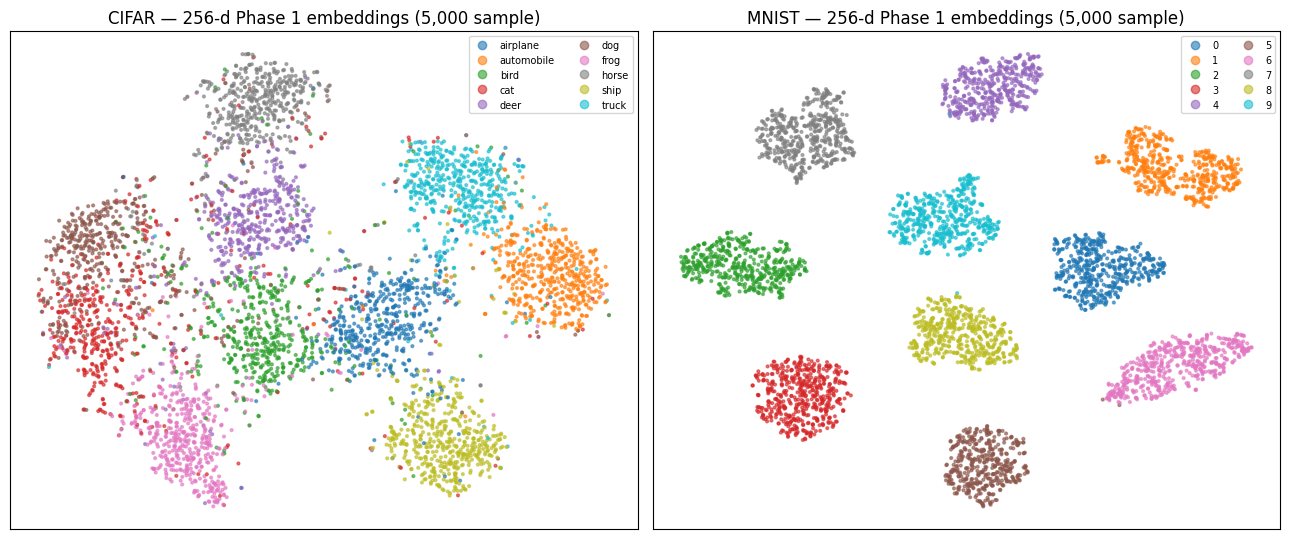

In [16]:
# ── t-SNE projection (qualitative figure, not a test) ──────────
# 5,000-point subsample: t-SNE is slow at 50k and the plot would be an unreadable blob.
# init='pca' with a fixed random_state makes the layout reproducible.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, key in zip(axes, ['cifar', 'mnist']):
    rng = np.random.default_rng(42)
    sub = rng.choice(len(EMB_N[key][42]), 5000, replace=False)
    Z   = TSNE(n_components=2, init='pca', perplexity=30,
               random_state=42).fit_transform(EMB_N[key][42][sub])
    sc  = ax.scatter(Z[:, 0], Z[:, 1], c=LAB[key][sub], cmap='tab10', s=4, alpha=0.6)
    ax.legend(sc.legend_elements()[0], CLASS_NAMES[key], fontsize=7, loc='best', ncol=2)
    ax.set_title(f'{key.upper()} — 256-d Phase 1 embeddings (5,000 sample)')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/phase4_tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 - Selection Functions

`sample_indices(dataset, fraction, seed) -> list[int]` keeps the **fixed signature** used in Phases
2 and 3. It is the only function that changes between phases.

### Quota logic - identical to Phase 3
`n_sample = max(1, int(n_total * fraction))`, `base = n_sample // 10`, and the remainder is handed
out one per class to the first `remainder` classes. For all five configured subset sizes the
remainder is zero (CIFAR → 10/25/50/100/250 per class; MNIST → 12/30/60/120/300), so the branch is
inert in practice — it is retained so the logic is byte-identical to Phase 3.

### Within-class selection - the only thing that differs
For each class, K-means partitions that class's embeddings into `k` = quota clusters, and the image
**nearest each centroid** is kept. A centroid is a synthetic vector with no image attached, so the
nearest real point stands in for it.

Two implementation choices worth defending in the viva:

- **Candidates are restricted to each cluster's own members.** Since K-means assigns every point to
  exactly one cluster, nearest-within-cluster picks are automatically distinct — duplicate selection
  becomes *structurally impossible* rather than something patched up afterwards.
- **`n_init=1`.** The default `n_init=10` would run ten restarts and keep the best, which would
  average away the seed's effect (defeating the purpose of running five seeds) and cost ten times as
  much across the 500 K-means fits this notebook performs.

### Caching
Selected indices are cached as JSON, keyed by dataset, fraction, seed and a **config hash**. The hash
means that changing any methodological choice automatically invalidates every cached file — without
it, fixing a bug mid-project would silently reuse the old subsets. The JSON files are small enough to
commit, so the exact subsets are reproducible without a GPU.

### Phase 2 and Phase 3 replicas
`sample_indices_p2` and `sample_indices_p3` are copied verbatim from those notebooks, purely so the
diagnostics can compare selections. They are pure, seed-deterministic functions: running them
regenerates the exact subsets those phases used. **Nothing in Phases 2 or 3 is modified.**


In [17]:
INDEX_CACHE = f'{CACHE_DIR}/indices'
os.makedirs(INDEX_CACHE, exist_ok=True)

# Any change to these fields invalidates every cached index file.
P4_CONFIG = {
    'layer':         'classifier[2] ReLU 256d',
    'checkpoint':    'per_seed',            # run seed s uses the seed-s Phase 1 checkpoint
    'l2_normalised': True,
    'kmeans_n_init': 1,
    'pick':          'nearest_in_cluster',
}
P4_HASH = hashlib.md5(json.dumps(P4_CONFIG, sort_keys=True).encode()).hexdigest()[:8]
FORCE_RECOMPUTE = False        # set True to ignore the index cache entirely
print(f'Phase 4 config hash: {P4_HASH}')


def _dataset_key(dataset) -> str:
    """Map a torchvision dataset OBJECT to the short key used in EMB_N / LAB.
    Doing the lookup here keeps sample_indices' signature identical to Phases 2/3."""
    return DS_KEY[type(dataset).__name__]      # 'MNIST' / 'CIFAR10' -> 'mnist' / 'cifar'


def sample_indices(dataset, fraction: float, seed: int) -> list:
    """
    PHASE 4: per-class K-means coreset selection.

    Quota logic is identical to Phase 3, so both phases draw the SAME number of images
    from the SAME classes. Only the within-class choice differs: Phase 3 picks at random,
    Phase 4 picks the image nearest each cluster centroid.

    Coleman et al. 2020 (SVP) — https://arxiv.org/abs/1906.11829
    """
    key      = _dataset_key(dataset)
    n_total  = len(dataset)
    n_sample = max(1, int(n_total * fraction))       # identical to Phases 2 and 3

    cache_f = f'{INDEX_CACHE}/{key}_f{fraction}_s{seed}_{P4_HASH}.json'
    if os.path.exists(cache_f) and not FORCE_RECOMPUTE:
        return json.load(open(cache_f))['indices']

    X      = EMB_N[key][seed]                        # per-seed, L2-normalised feature space
    labels = LAB[key]
    assert len(X) == n_total, 'embedding/dataset length mismatch — stale cache?'

    classes     = np.unique(labels)
    num_classes = len(classes)
    base        = n_sample // num_classes
    remainder   = n_sample %  num_classes            # zero for all five configured sizes
    assert base >= 1, (f'Subset of {n_sample} is too small for {num_classes} classes '
                       f'(<1 per class).')

    selected = []
    for k, cls in enumerate(classes):
        quota   = base + (1 if k < remainder else 0)     # spread the remainder, as in Phase 3
        cls_idx = np.where(labels == cls)[0]             # dataset indices belonging to this class
        Xc      = X[cls_idx]                             # embeddings for this class only

        # K-means WITHIN the class: k = the per-class quota, so every cluster
        # contributes exactly one image and the class balance of Phase 3 is preserved.
        km = KMeans(n_clusters=quota, n_init=1, random_state=seed).fit(Xc)

        chosen = []
        for j in range(quota):
            members = np.where(km.labels_ == j)[0]       # points assigned to cluster j
            if len(members) == 0:
                # Empty cluster (rare — sklearn normally relocates centroids). Fall back to
                # the k-centers rule: take the unselected point FURTHEST from everything
                # already chosen, i.e. maximise coverage (Coleman et al. 2020).
                pool = np.setdiff1d(np.arange(len(Xc)), chosen)
                d    = np.linalg.norm(Xc[pool][:, None] - Xc[chosen][None], axis=2).min(axis=1)
                chosen.append(int(pool[d.argmax()]))
                continue
            # Restricting candidates to this cluster's members makes duplicate picks
            # structurally impossible: each point belongs to exactly one cluster.
            d = np.linalg.norm(Xc[members] - km.cluster_centers_[j], axis=1)
            chosen.append(int(members[d.argmin()]))

        assert len(set(chosen)) == quota, f'duplicate pick inside class {cls}'
        selected.extend(cls_idx[chosen].tolist())

    # Shuffle so the saved list is not class-ordered. Purely cosmetic — the DataLoader
    # reshuffles every epoch. Isolated RNG: never touches the global random state.
    np.random.default_rng(seed).shuffle(selected)

    # ── Proof of correctness, not an assumption ────────────────
    assert len(selected)      == n_sample, f'got {len(selected)}, expected {n_sample}'
    assert len(set(selected)) == n_sample, 'duplicate indices in the final subset'
    counts = np.bincount(labels[selected], minlength=num_classes)
    expect = [base + (1 if k < remainder else 0) for k in range(num_classes)]
    assert list(counts) == expect, f'class counts {list(counts)} != quota {expect}'

    json.dump({'indices': selected, 'config': P4_CONFIG, 'hash': P4_HASH,
               'dataset': key, 'fraction': fraction, 'seed': seed}, open(cache_f, 'w'))
    return selected


# ══ Replicas of the locked phases — for diagnostics only ══

def sample_indices_p2(dataset, fraction: float, seed: int) -> list:
    """PHASE 2 (verbatim): uniform random over the whole training set."""
    rng      = np.random.default_rng(seed)
    n_total  = len(dataset)
    n_sample = max(1, int(n_total * fraction))
    return rng.choice(n_total, size=n_sample, replace=False).tolist()


def sample_indices_p3(dataset, fraction: float, seed: int) -> list:
    """PHASE 3 (verbatim): class-balanced, random WITHIN each class."""
    rng      = np.random.default_rng(seed)
    n_total  = len(dataset)
    n_sample = max(1, int(n_total * fraction))
    labels      = np.asarray(dataset.targets)
    classes     = np.unique(labels)
    num_classes = len(classes)
    base        = n_sample // num_classes
    remainder   = n_sample %  num_classes
    selected = []
    for k, cls in enumerate(classes):
        cls_indices = np.where(labels == cls)[0]
        quota       = base + (1 if k < remainder else 0)
        chosen      = rng.choice(cls_indices, size=quota, replace=False)
        selected.extend(chosen.tolist())
    rng.shuffle(selected)
    return selected

Phase 4 config hash: 13077f1d


## Section 9 - Selection Correctness Tests

Run before any training. These verify that Phase 4 produces subsets of exactly the right size, with
exactly the Phase 3 per-class quota, with no duplicates, and deterministically for a given seed.

The determinism check matters because scikit-learn's Lloyd algorithm is threaded, so bit-exact
reproducibility across machines is not guaranteed even with `random_state` fixed. If the check fails,
the index cache still guarantees reproducibility (the JSON is written once and reused) — but the
write-up must then say that, rather than claim bit-exactness it does not have.


In [18]:
# sample_indices only reads `.targets` and `len()`, never pixels, so the eval-transform
# dataset is the appropriate object to pass here.
DS_SEL = {'mnist': get_eval_trainset('mnist'), 'cifar': get_eval_trainset('cifar')}

for key in ['cifar', 'mnist']:
    print(f"\n{'=' * 64}\n  {key.upper()} — selection tests (seed 42)\n{'=' * 64}")
    print(f"  {'size':<7}{'n':>7}{'per-class':>13}{'unique':>9}{'sec':>7}")
    for frac, label in zip(SUBSET_FRACS, SUBSET_LABELS):
        t0   = time.time()
        idx  = sample_indices(DS_SEL[key], frac, seed=42)
        dt   = time.time() - t0
        cnt  = np.bincount(LAB[key][idx], minlength=10)
        uniq = 'yes' if len(set(idx)) == len(idx) else 'NO'
        print(f'  {label:<7}{len(idx):>7}{cnt.min():>7}-{cnt.max():<5}{uniq:>9}{dt:>7.1f}')

# Determinism: recomputing with the same seed must give the same subset.
a = sample_indices(DS_SEL['cifar'], 0.05, 42)
FORCE_RECOMPUTE = True                       # bypass the cache so this is a genuine re-run
b = sample_indices(DS_SEL['cifar'], 0.05, 42)
FORCE_RECOMPUTE = False
print(f'\nDeterminism (CIFAR 5%, seed 42, recomputed): {sorted(a) == sorted(b)}')


  CIFAR — selection tests (seed 42)
  size         n    per-class   unique    sec
  0.2%       100     10-10         yes    1.4
  0.5%       250     25-25         yes    2.6
  1%         500     50-50         yes    3.7
  2%        1000    100-100        yes    6.3
  5%        2500    250-250        yes   13.0

  MNIST — selection tests (seed 42)
  size         n    per-class   unique    sec
  0.2%       120     12-12         yes    1.6
  0.5%       300     30-30         yes    3.5
  1%         600     60-60         yes    5.1
  2%        1200    120-120        yes    8.4
  5%        3000    300-300        yes   18.9

Determinism (CIFAR 5%, seed 42, recomputed): True


## Section 10 - Selection Self-Consistency

### A diagnostic that was designed, run, and then discarded
An earlier version of this notebook compared the Phase 4 selection against the Phase 3 selection
using the Jaccard index, on the reasoning that a low overlap would show K-means selecting no
differently from random. **That test is uninformative by construction, and it is documented here
rather than quietly deleted.**

If K-means picks a deterministic set *S* of size *k* from *N* points, and Phase 3 picks a uniform
random set *R* of the same size, then

$$\mathbb{E}|S \cap R| = k \cdot \frac{k}{N}$$

*regardless of how structured S is*, because *R* is uniform and has no preference for any particular
image. Working the Jaccard through gives *f*/(2 − *f*) — exactly the random-versus-random baseline it
was being compared against. The test could only exceed its own baseline if K-means preferred images
that uniform sampling also preferred, which is impossible. It therefore cannot distinguish a
structured selection from a random one, and its result carries no information.

### The test that does carry information
**Seed-to-seed self-consistency.** Each seed uses a *different* Phase 1 checkpoint, hence a different
256-d feature space, and a different K-means initialisation. If the five resulting selections overlap
more than chance, K-means is recovering structure that exists in the *data* rather than in any one
model or initialisation.

The same *f*/(2 − *f*) expression is the correct null here, and it is a meaningful comparison in this
case: two runs of a purely random selector would sit at the baseline, so exceeding it is evidence of
genuine agreement.


In [19]:
def jaccard(a, b) -> float:
    """|A n B| / |A u B| — 0.0 = disjoint, 1.0 = identical."""
    A, B = set(a), set(b)
    return len(A & B) / len(A | B)


print(f"{'ds':<7}{'size':<7}{'mean J':>9}{'null':>9}{'ratio':>8}  interpretation")
print('-' * 60)
SELF_CONSISTENCY = {}
for key in ['cifar', 'mnist']:
    for frac, label in zip(SUBSET_FRACS, SUBSET_LABELS):
        sel  = {s: sample_indices(DS_SEL[key], frac, s) for s in SEEDS}
        pair = [jaccard(sel[a], sel[b]) for a, b in itertools.combinations(SEEDS, 2)]
        mean_j = float(np.mean(pair))
        null   = frac / (2 - frac)              # two independent random selections of this size
        ratio  = mean_j / null
        interp = ('strong agreement' if ratio > 2.0 else
                  'above chance'     if ratio > 1.3 else
                  'near chance')
        SELF_CONSISTENCY[f'{key}_{label}'] = {'mean_jaccard': mean_j, 'null': null,
                                              'ratio': ratio, 'pairwise': pair}
        print(f'{key:<7}{label:<7}{mean_j:>9.4f}{null:>9.4f}{ratio:>8.2f}  {interp}')

print('\nEach seed uses a DIFFERENT Phase 1 checkpoint, so agreement above the null')
print('means K-means is recovering structure in the data, not in one model or one init.')

ds     size      mean J     null   ratio  interpretation
------------------------------------------------------------
cifar  0.2%      0.0055   0.0010    5.54  strong agreement
cifar  0.5%      0.0099   0.0025    3.95  strong agreement
cifar  1%        0.0122   0.0050    2.42  strong agreement
cifar  2%        0.0198   0.0101    1.97  above chance
cifar  5%        0.0403   0.0256    1.57  above chance
mnist  0.2%      0.0050   0.0010    5.03  strong agreement
mnist  0.5%      0.0055   0.0025    2.21  strong agreement
mnist  1%        0.0112   0.0050    2.23  strong agreement
mnist  2%        0.0178   0.0101    1.76  above chance
mnist  5%        0.0461   0.0256    1.80  above chance

Each seed uses a DIFFERENT Phase 1 checkpoint, so agreement above the null
means K-means is recovering structure in the data, not in one model or one init.


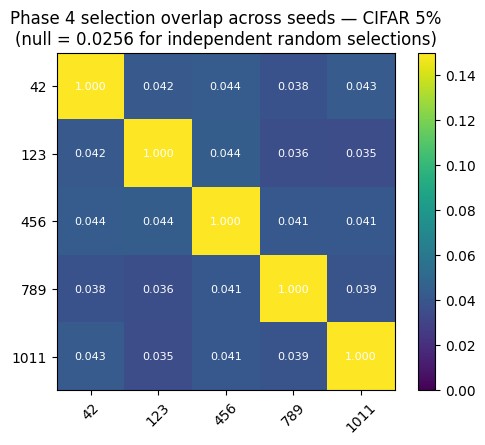

In [20]:
# ── Pairwise heatmap for the largest CIFAR subset ──────────────
sel = {s: sample_indices(DS_SEL['cifar'], 0.05, s) for s in SEEDS}
M   = np.eye(len(SEEDS))
for i, j in itertools.combinations(range(len(SEEDS)), 2):
    M[i, j] = M[j, i] = jaccard(sel[SEEDS[i]], sel[SEEDS[j]])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap='viridis', vmin=0, vmax=max(0.15, M[~np.eye(5, dtype=bool)].max() * 1.2))
ax.set_xticks(range(5)); ax.set_xticklabels(SEEDS, rotation=45)
ax.set_yticks(range(5)); ax.set_yticklabels(SEEDS)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', color='w', fontsize=8)
ax.set_title(f'Phase 4 selection overlap across seeds — CIFAR 5%\n'
             f'(null = {0.05 / 1.95:.4f} for independent random selections)')
plt.colorbar(im); plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/phase4_self_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 - Selection Visualisation

Qualitative check requested by the supervisor: humans are good at spotting *"all the selected cats
look the same"*, which no summary statistic captures.

Images are drawn from `get_raw_dataset` (`ToTensor()` only), so they display in true colour with no
normalisation or augmentation applied.

Two classes are shown, chosen to maximise contrast: **cat** (Phase 1 F1 0.6465, the loosest class in
embedding space and the only one with a *negative* silhouette) and **automobile** (F1 0.9055, among
the tightest).

Rows follow `CLASS_ORDER` — hardest class first — which is the **same ordering used in every figure
in this phase**, so a reader comparing figures never has to re-learn the order.


Grid row order (hardest -> easiest): ['cat', 'automobile']


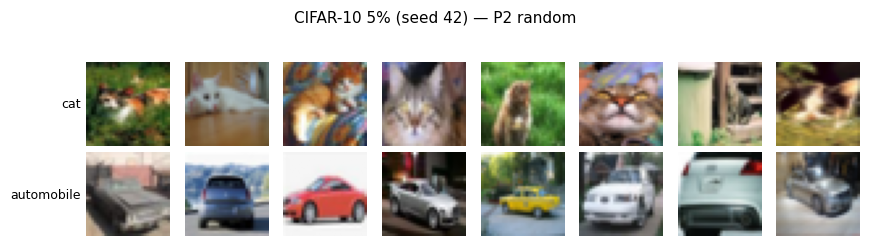

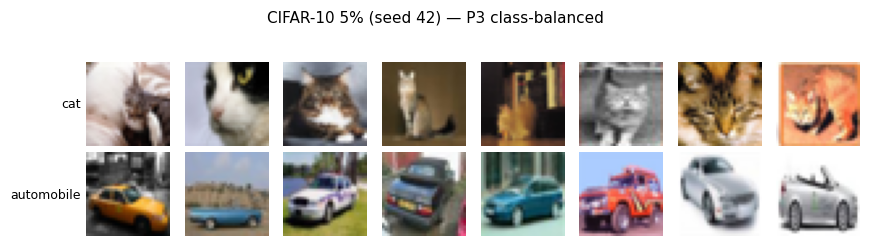

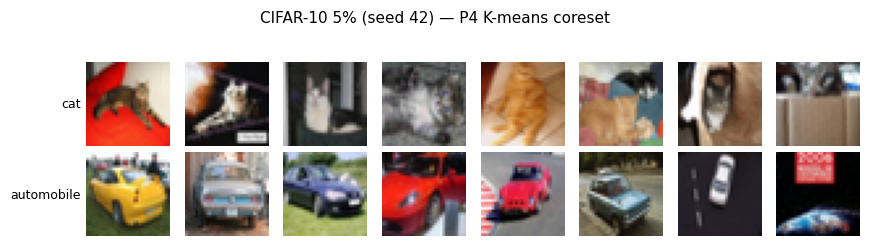

In [21]:
def plot_selection_grid(key, indices, title, save_path, classes_to_show=None, n_per_class=8):
    """Display the first `n_per_class` selected images for each chosen class.
    Uses the raw (unnormalised, unaugmented) dataset so colours are true."""
    raw     = get_raw_dataset(key)
    labels  = LAB[key]
    names   = CLASS_NAMES[key]
    classes = classes_to_show if classes_to_show is not None else list(range(10))
    idx_arr = np.asarray(indices)

    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 1.1, len(classes) * 1.25))
    axes = np.atleast_2d(axes)

    for r, c in enumerate(classes):
        picks = idx_arr[labels[idx_arr] == c][:n_per_class]
        for col in range(n_per_class):
            ax = axes[r, col]
            ax.axis('off')
            if col < len(picks):
                img = raw[int(picks[col])][0]                # (C, H, W) in [0, 1]
                ax.imshow(img.squeeze(0) if img.shape[0] == 1 else img.permute(1, 2, 0),
                          cmap='gray' if img.shape[0] == 1 else None)
            if col == 0:
                ax.set_ylabel(names[c], rotation=0, ha='right', va='center', fontsize=9)
                ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_visible(False)

    fig.suptitle(title, fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Rows follow CLASS_ORDER (hardest -> easiest), the same ordering used in every other
# figure in this phase. Showing the two extremes: cat (hardest, F1 0.6465, and the only
# class with a NEGATIVE silhouette) and automobile (easiest, F1 0.9055).
SHOW = [CLASS_NAMES['cifar'].index(c) for c in (CLASS_ORDER['cifar'][0],
                                                CLASS_ORDER['cifar'][-1])]
print('Grid row order (hardest -> easiest):',
      [CLASS_NAMES['cifar'][i] for i in SHOW])

for tag, fn in [('P2 random', sample_indices_p2),
                ('P3 class-balanced', sample_indices_p3),
                ('P4 K-means coreset', sample_indices)]:
    idx = fn(DS_SEL['cifar'], 0.05, 42)
    plot_selection_grid(
        'cifar', idx,
        title=f'CIFAR-10 5% (seed 42) — {tag}',
        save_path=f"{FIGURES_DIR}/phase4_grid_{tag.split()[0]}.png",
        classes_to_show=SHOW)

## Section 12 - Training Harness

Copied **verbatim** from Phase 2. `train_epoch`, `evaluate`, and the nested
`dataset → subset_size → seed` loop are unchanged, including the DataLoader seeding, the
`batch_size=min(BATCH_SIZE, len(subset))` guard for subsets smaller than one batch, fresh model
initialisation on every run, and the scheduler stepping on **training** loss.

This is deliberate and load-bearing. Phase 4's entire claim rests on `(Phase 4 − Phase 3)` isolating
the selection strategy. That only holds if every other component is identical — so the harness is
copied rather than rewritten.

The single substitution is `sample_indices`, which now performs K-means coreset selection.

**50 runs total** (2 datasets × 5 subset sizes × 5 seeds), roughly 10 minutes on a T4. The fractions
sum to 8.7%, so a full CIFAR sweep is about 0.44× the cost of a *single* Phase 1 run.


In [22]:
def train_epoch(model, loader, criterion, optimiser, device):
    """One training pass. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * images.size(0)  # un-average to sum over the batch
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, device):
    """Full evaluation on the test set. Returns (top1_pct, macro_f1, per_class_f1_array)."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():  # disables gradient tracking — no memory allocated for gradients
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    top1         = (all_preds == all_labels).mean() * 100
    macro_f1     = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None,    zero_division=0)

    return top1, macro_f1, per_class_f1

In [23]:
DATASET_CONFIGS = {
    'MNIST':   {'in_channels': 1},
    'CIFAR10': {'in_channels': 3},
}

results = {}  # results[ds_name][label][str(seed)] = {top1, macro_f1, per_class_f1}
run_start = time.time()

for ds_name, ds_cfg in DATASET_CONFIGS.items():
    print(f"\n{'=' * 60}\nDataset: {ds_name}\n{'=' * 60}")
    results[ds_name] = {}

    train_ds, test_ds = get_datasets(ds_name)

    # Test loader — fixed, never subsampled, identical across all phases
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    for frac, label in zip(SUBSET_FRACS, SUBSET_LABELS):
        n_samples = max(1, int(len(train_ds) * frac))
        print(f'\n  -- Subset {label} ({n_samples} samples) --')
        results[ds_name][label] = {}

        for seed in SEEDS:
            t0 = time.time()
            set_seed(seed)  # fix global state FIRST, before any other operation

            # -- Sample: PHASE 4 K-means coreset (the only change from Phase 2) --
            indices = sample_indices(train_ds, frac, seed)
            subset  = Subset(train_ds, indices)              # index-based view, no data copy

            g = torch.Generator()
            g.manual_seed(seed)  # seeds the DataLoader shuffle order

            train_loader = DataLoader(
                subset,
                batch_size=min(BATCH_SIZE, len(subset)),  # guard: subset may be smaller than 128
                shuffle=True,
                num_workers=NUM_WORKERS,
                worker_init_fn=seed_worker,   # seeds each worker subprocess
                generator=g,                  # seeds the shuffle permutation
                pin_memory=True               # speeds up CPU->GPU transfer
            )

            # -- Model: fresh init every run, no state leaks across seeds --
            model     = SimpleCNN(in_channels=ds_cfg['in_channels']).to(DEVICE)
            criterion = nn.CrossEntropyLoss()
            optimiser = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=3
            )

            # -- Train --
            for epoch in range(EPOCHS[ds_name]):
                train_loss, train_acc = train_epoch(
                    model, train_loader, criterion, optimiser, DEVICE
                )
                scheduler.step(train_loss)  # scheduler watches TRAINING loss (no validation split)

            # -- Evaluate on the full test set --
            top1, macro_f1, per_class_f1 = evaluate(model, test_loader, DEVICE)

            # -- Save checkpoint --
            label_clean = label.replace('%', 'pct')
            ckpt_name   = f'phase4_kmeans_{ds_name}_seed{seed}_{label_clean}.pth'
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, ckpt_name))

            # -- Record results --
            results[ds_name][label][str(seed)] = {
                'top1':         round(top1, 4),
                'macro_f1':     round(macro_f1, 6),
                'per_class_f1': per_class_f1.tolist()
            }

            print(f'    seed={seed} | Top-1={top1:.2f}% | Macro-F1={macro_f1:.4f} | '
                  f'{time.time() - t0:.0f}s')

results_path = os.path.join(RESULTS_DIR, 'phase4_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nTotal run time: {(time.time() - run_start) / 60:.1f} min')
print(f'Results saved -> {results_path}')


Dataset: MNIST

  -- Subset 0.2% (120 samples) --
    seed=42 | Top-1=22.65% | Macro-F1=0.1596 | 4s
    seed=123 | Top-1=35.07% | Macro-F1=0.3124 | 3s
    seed=456 | Top-1=27.18% | Macro-F1=0.1963 | 4s
    seed=789 | Top-1=22.33% | Macro-F1=0.1539 | 4s
    seed=1011 | Top-1=38.96% | Macro-F1=0.2846 | 4s

  -- Subset 0.5% (300 samples) --
    seed=42 | Top-1=82.56% | Macro-F1=0.8208 | 4s
    seed=123 | Top-1=86.62% | Macro-F1=0.8574 | 4s
    seed=456 | Top-1=86.42% | Macro-F1=0.8670 | 4s
    seed=789 | Top-1=88.01% | Macro-F1=0.8788 | 4s
    seed=1011 | Top-1=93.08% | Macro-F1=0.9308 | 4s

  -- Subset 1% (600 samples) --
    seed=42 | Top-1=95.03% | Macro-F1=0.9498 | 5s
    seed=123 | Top-1=94.18% | Macro-F1=0.9415 | 5s
    seed=456 | Top-1=92.14% | Macro-F1=0.9215 | 5s
    seed=789 | Top-1=93.87% | Macro-F1=0.9378 | 5s
    seed=1011 | Top-1=94.76% | Macro-F1=0.9474 | 5s

  -- Subset 2% (1200 samples) --
    seed=42 | Top-1=96.83% | Macro-F1=0.9680 | 6s
    seed=123 | Top-1=95.30% | Ma

## Section 13 - Aggregation

`aggregate` is copied verbatim from Phase 2. It additionally retains `seed_top1`, the raw per-seed
values, which the paired test in Section 14 requires.

A **monotonicity check** is included. Accuracy should increase with subset size; any decrease
indicates that training instability, not selection quality, is dominating at that point. Flagging it
here means it is reported rather than discovered by a marker.

**Note on reference constants.** The Phase 3 MNIST values used here were corrected against
`phase3_results.json`, which is authoritative. The previously recorded figures
(25.67 / 90.42 / 93.98 / 95.10 / 96.12) were slightly wrong; the CIFAR values were correct and are
unchanged. Every table, statistic and figure below is generated from the corrected constants.


In [24]:
def aggregate(results: dict, ds_name: str) -> dict:
    """Compute mean +/- std across seeds for each subset size."""
    summary = {}
    for label in SUBSET_LABELS:
        seed_top1 = [results[ds_name][label][str(s)]['top1']     for s in SEEDS]
        seed_f1   = [results[ds_name][label][str(s)]['macro_f1'] for s in SEEDS]
        per_class = np.array(
            [results[ds_name][label][str(s)]['per_class_f1'] for s in SEEDS]
        )  # shape: (5 seeds, 10 classes)

        summary[label] = {
            'top1_mean':         np.mean(seed_top1),
            'top1_std':          np.std(seed_top1),
            'f1_mean':           np.mean(seed_f1),
            'f1_std':            np.std(seed_f1),
            'per_class_f1_mean': per_class.mean(axis=0).tolist(),
            'per_class_f1_std':  per_class.std(axis=0).tolist(),
            'seed_top1':         seed_top1,  # raw per-seed values, needed for the paired test
        }
    return summary


SUMMARY = {ds: aggregate(results, ds) for ds in ['MNIST', 'CIFAR10']}

for ds_name in ['MNIST', 'CIFAR10']:
    summ = SUMMARY[ds_name]
    print(f"\n{'-' * 74}")
    print(f'{ds_name} — Phase 4 Summary  (mean +/- std, n={len(SEEDS)} seeds)')
    print(f"{'-' * 74}")
    print(f"{'Subset':<8}{'Top-1':>9}{'+/-Std':>8}{'F1':>9}{'+/-Std':>8}"
          f"{'P2':>8}{'P3':>8}{'d(P4-P3)':>11}")
    print(f"{'-' * 74}")
    for i, label in enumerate(SUBSET_LABELS):
        s = summ[label]
        print(f"{label:<8}{s['top1_mean']:>8.2f}%{s['top1_std']:>7.2f}%"
              f"{s['f1_mean']:>9.4f}{s['f1_std']:>8.4f}"
              f"{P2_TOP1[ds_name][i]:>7.2f}%{P3_TOP1[ds_name][i]:>7.2f}%"
              f"{s['top1_mean'] - P3_TOP1[ds_name][i]:>+10.2f}pp")
    print(f"\n  Phase 1 ceiling (full dataset): {P1[ds_name]['top1']:.2f}%")

    # Monotonicity: accuracy should rise with subset size. A fall means training
    # instability at that size is dominating the effect of selection.
    means = [summ[l]['top1_mean'] for l in SUBSET_LABELS]
    drops = [(SUBSET_LABELS[i], SUBSET_LABELS[i + 1], means[i + 1] - means[i])
             for i in range(len(means) - 1) if means[i + 1] < means[i]]
    if drops:
        for a, b, d in drops:
            print(f'  NON-MONOTONIC: {a} -> {b} falls {d:+.2f}pp '
                  f"(std at {b} = {summ[b]['top1_std']:.2f}% — training instability, "
                  f'not selection)')
    else:
        print('  Monotonic in subset size: OK')


--------------------------------------------------------------------------
MNIST — Phase 4 Summary  (mean +/- std, n=5 seeds)
--------------------------------------------------------------------------
Subset      Top-1  +/-Std       F1  +/-Std      P2      P3   d(P4-P3)
--------------------------------------------------------------------------
0.2%       29.24%   6.69%   0.2214  0.0652  24.31%  25.74%     +3.50pp
0.5%       87.34%   3.39%   0.8709  0.0357  82.03%  90.40%     -3.06pp
1%         94.00%   1.01%   0.9396  0.0100  94.54%  94.23%     -0.23pp
2%         93.57%   2.91%   0.9367  0.0277  95.68%  95.38%     -1.81pp
5%         96.76%   0.91%   0.9675  0.0089  96.87%  96.16%     +0.60pp

  Phase 1 ceiling (full dataset): 98.98%
  NON-MONOTONIC: 1% -> 2% falls -0.43pp (std at 2% = 2.91% — training instability, not selection)

--------------------------------------------------------------------------
CIFAR10 — Phase 4 Summary  (mean +/- std, n=5 seeds)
-----------------------------

## Section 14 - Paired Comparison Against Phase 3

### Why a paired test
Phases 2 and 3 were compared with overlapping mean ± std bars. With only five seeds, that comparison
is badly underpowered. Phase 4 versus Phase 3 is a **paired** design: for a given seed, both phases
use the same model initialisation, the same DataLoader shuffle order and the same per-class quota.
Only the within-class picks differ.

In practice the pairing recovers less power than expected here, because Phase 4's selection is close
to deterministic while Phase 3's is random, so the two are only weakly correlated across seeds.

### Power
With n = 5, this test detects only large effects. Required sample size for 80% power at α = 0.05 is
approximately n ≈ 7.85/d², so the observed effect sizes would need roughly 14–35 seeds. This is
computed explicitly below and reported as a **declared limitation** rather than concealed.

**Additional seeds were considered and deliberately rejected.** Only five Phase 1 checkpoints exist,
so additional seeds would cycle the same feature spaces — varying training and K-means initialisation
but not the embedding space under test. These would be pseudo-replicates rather than independent
replicates, inflating apparent power without adding information about the quantity of interest. The
underpowering is therefore reported as a declared limitation rather than concealed by
non-independent resampling.

**This limitation is project-wide.** Phases 2 and 3 used the same five seeds and are subject to the
same constraint.


In [25]:
def find_results(fname: str):
    """Locate a results JSON anywhere under /kaggle/input."""
    hits = glob.glob(f'/kaggle/input/**/{fname}', recursive=True)
    return json.load(open(hits[0])) if hits else None


p3_results = find_results('phase3_results.json')
p2_results = find_results('phase2_results.json')
print(f"phase3_results.json: {'FOUND' if p3_results else 'NOT FOUND'}")
print(f"phase2_results.json: {'FOUND' if p2_results else 'NOT FOUND'}")

PAIRED = {}
if p3_results is None:
    print('\nFalling back to a means-only comparison. This is WEAKER than the planned')
    print('paired test and must be described as such in the write-up.')
else:
    # Two-tailed paired t-test at alpha=0.05, power=0.80:
    #   n ~= (z_0.975 + z_0.80)^2 / d^2 = (1.960 + 0.842)^2 / d^2 = 7.85 / d^2
    Z_SUM_SQ = (1.95996 + 0.84162) ** 2

    print(f"\n{'ds':<9}{'size':<7}{'P4':>9}{'P3':>9}{'delta':>9}"
          f"{'t':>8}{'p':>9}{'d':>8}{'n for 80%':>11}  verdict")
    print('-' * 86)
    for ds_name in ['MNIST', 'CIFAR10']:
        for label in SUBSET_LABELS:
            p4   = np.array(SUMMARY[ds_name][label]['seed_top1'])
            p3   = np.array([p3_results[ds_name][label][str(s)]['top1'] for s in SEEDS])
            diff = p4 - p3                                   # paired per-seed differences

            t_stat, p_val = ttest_rel(p4, p3)
            sd = diff.std(ddof=1)          # ddof=1: population sd estimated from 5 observations
            d  = diff.mean() / sd if sd > 0 else np.nan
            n_needed = int(np.ceil(Z_SUM_SQ / d**2)) if (d and not np.isnan(d)) else None

            verdict = ('significant' if p_val < 0.05 else
                       'trend'       if p_val < 0.10 else 'no effect')
            PAIRED[f'{ds_name}_{label}'] = {
                'p4_mean': float(p4.mean()), 'p3_mean': float(p3.mean()),
                'delta': float(diff.mean()), 't': float(t_stat), 'p': float(p_val),
                'cohens_d': float(d), 'n_for_80pct_power': n_needed,
                'per_seed_diff': diff.tolist(),
            }
            print(f'{ds_name:<9}{label:<7}{p4.mean():>8.2f}%{p3.mean():>8.2f}%'
                  f'{diff.mean():>+8.2f}p{t_stat:>8.2f}{p_val:>9.4f}{d:>8.2f}'
                  f'{str(n_needed):>11}  {verdict}')

    json.dump(PAIRED, open(f'{RESULTS_DIR}/phase4_paired_vs_phase3.json', 'w'), indent=2)
    print(f'\nSaved -> {RESULTS_DIR}/phase4_paired_vs_phase3.json')
    print('\nDECLARED LIMITATION: five seeds were run. The effect sizes observed would')
    print('require the sample sizes in the final column to be detectable at 80% power.')
    print('Additional seeds were rejected as pseudo-replicates (see markdown above).')

phase3_results.json: FOUND
phase2_results.json: FOUND

ds       size          P4       P3    delta       t        p       d  n for 80%  verdict
--------------------------------------------------------------------------------------
MNIST    0.2%      29.24%   25.74%   +3.50p    1.08   0.3403    0.48         34  no effect
MNIST    0.5%      87.34%   90.40%   -3.06p   -2.51   0.0658   -1.12          7  trend
MNIST    1%        94.00%   94.23%   -0.23p   -0.25   0.8156   -0.11        634  no effect
MNIST    2%        93.57%   95.38%   -1.82p   -1.40   0.2347   -0.63         21  no effect
MNIST    5%        96.76%   96.16%   +0.60p    0.57   0.5998    0.25        122  no effect
CIFAR10  0.2%      26.16%   23.33%   +2.83p    1.62   0.1807    0.72         15  no effect
CIFAR10  0.5%      34.93%   33.03%   +1.90p    1.69   0.1655    0.76         14  no effect
CIFAR10  1%        42.84%   40.50%   +2.33p    1.08   0.3407    0.48         34  no effect
CIFAR10  2%        49.35%   50.28%   -0.93p  

## Section 15  Subset-Size Trend (descriptive only)

The pre-committed hypothesis was that K-means would close the CIFAR gap **in the 1–5% range**. This
section plots Δ = Phase 4 − Phase 3 against subset size and reports where the sign changes.

> **DESCRIPTIVE ONLY.** Every paired test in Section 14 is non-significant, so the sign pattern
> below is an observation about point estimates, **not a finding**. It must not be phrased as one
> anywhere in the dissertation or on the poster.

A directional prediction exists in the literature — that the optimal pruning direction depends on
data abundance, with prototypical examples favoured when data is scarce. Centroid-nearest selection
keeps the most prototypical example per cluster, so this would predict help in the scarce regime and
none as data becomes plentiful.

> **CITATION NOT YET VERIFIED.** This is attributed to Sorscher et al. 2022 from memory and has
> **not** been checked against the paper. It must not be cited in any submitted output until the
> exact claim has been read and confirmed at source. The same applies in Phase 5.

The detector runs on **CIFAR-10 only**. MNIST's deltas oscillate within its noise band (±6.66pp at
0.2%), so a sign change there would reflect training instability rather than any property of the
selection method, and reporting one would put an unsupported claim in the output.


In [26]:
CROSSOVER_DATASETS = ['CIFAR10']      # MNIST excluded: deltas oscillate within its noise band

print(f"{'ds':<9}{'size':<7}{'n':>7}{'P4':>9}{'P3':>9}{'d vs P3':>10}{'d vs P2':>10}")
print('-' * 61)
CROSSOVER = {}
for ds_name in ['MNIST', 'CIFAR10']:
    n_total = 60000 if ds_name == 'MNIST' else 50000
    deltas  = []
    for i, label in enumerate(SUBSET_LABELS):
        p4 = SUMMARY[ds_name][label]['top1_mean']
        d3 = p4 - P3_TOP1[ds_name][i]
        deltas.append(d3)
        print(f'{ds_name:<9}{label:<7}{int(n_total * SUBSET_FRACS[i]):>7}'
              f'{p4:>8.2f}%{P3_TOP1[ds_name][i]:>8.2f}%{d3:>+9.2f}pp'
              f'{p4 - P2_TOP1[ds_name][i]:>+9.2f}pp')

    if ds_name not in CROSSOVER_DATASETS:
        CROSSOVER[ds_name] = {'between': None, 'deltas': deltas,
                              'note': 'detector not applied — deltas within noise band'}
        print(f'  --> sign-change detector NOT applied to {ds_name} '
              f'(deltas oscillate within noise).')
        print()
        continue

    signs = [np.sign(d) for d in deltas]
    cross = [(SUBSET_LABELS[i], SUBSET_LABELS[i + 1])
             for i in range(len(signs) - 1) if signs[i] > 0 and signs[i + 1] < 0]
    if cross:
        a, b = cross[0]
        na = int(n_total * SUBSET_FRACS[SUBSET_LABELS.index(a)])
        nb = int(n_total * SUBSET_FRACS[SUBSET_LABELS.index(b)])
        CROSSOVER[ds_name] = {'between': [a, b], 'n_between': [na, nb], 'deltas': deltas,
                              'status': 'DESCRIPTIVE ONLY — all paired tests non-significant'}
        print(f'  --> sign change between {a} and {b} ({na} and {nb} images).')
        print(f'      DESCRIPTIVE ONLY: all paired tests non-significant (Section 14).')
    else:
        CROSSOVER[ds_name] = {'between': None, 'deltas': deltas}
        print(f'  --> no sign change across the tested range.')
    print()

ds       size         n       P4       P3   d vs P3   d vs P2
-------------------------------------------------------------
MNIST    0.2%       120   29.24%   25.74%    +3.50pp    +4.93pp
MNIST    0.5%       300   87.34%   90.40%    -3.06pp    +5.31pp
MNIST    1%         600   94.00%   94.23%    -0.23pp    -0.54pp
MNIST    2%        1200   93.57%   95.38%    -1.81pp    -2.11pp
MNIST    5%        3000   96.76%   96.16%    +0.60pp    -0.11pp
  --> sign-change detector NOT applied to MNIST (deltas oscillate within noise).

CIFAR10  0.2%       100   26.16%   23.33%    +2.83pp    +2.87pp
CIFAR10  0.5%       250   34.93%   33.03%    +1.90pp    +1.81pp
CIFAR10  1%         500   42.84%   40.50%    +2.34pp    +2.76pp
CIFAR10  2%        1000   49.35%   50.28%    -0.93pp    +1.35pp
CIFAR10  5%        2500   56.74%   57.00%    -0.26pp    -1.31pp
  --> sign change between 1% and 2% (500 and 1000 images).
      DESCRIPTIVE ONLY: all paired tests non-significant (Section 14).



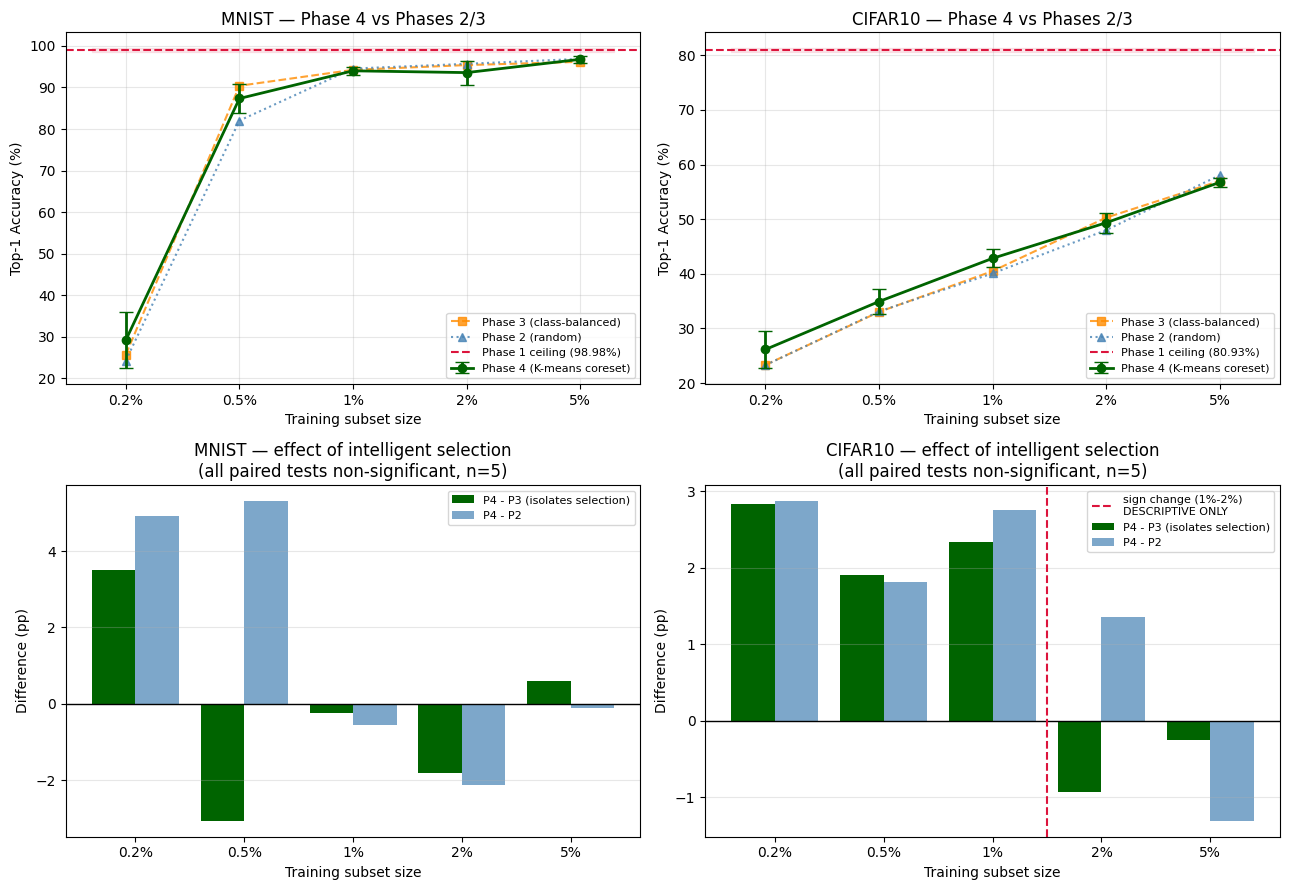

In [27]:
# ── Figure: accuracy curves and the delta-vs-size plot ─────────
# The x axis here is NUMERIC and already runs low -> high, so no re-sorting applies.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
x = np.arange(len(SUBSET_LABELS))

for col, ds_name in enumerate(['MNIST', 'CIFAR10']):
    summ  = SUMMARY[ds_name]
    means = [summ[l]['top1_mean'] for l in SUBSET_LABELS]
    stds  = [summ[l]['top1_std']  for l in SUBSET_LABELS]

    ax = axes[0, col]
    ax.errorbar(x, means, yerr=stds, marker='o', capsize=5, linewidth=2,
                color='darkgreen', label='Phase 4 (K-means coreset)', zorder=3)
    ax.plot(x, P3_TOP1[ds_name], marker='s', linestyle='--', linewidth=1.5,
            color='darkorange', alpha=0.8, label='Phase 3 (class-balanced)')
    ax.plot(x, P2_TOP1[ds_name], marker='^', linestyle=':', linewidth=1.5,
            color='steelblue', alpha=0.8, label='Phase 2 (random)')
    ceiling = P1[ds_name]['top1']
    ax.axhline(ceiling, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Phase 1 ceiling ({ceiling:.2f}%)')
    ax.fill_between([-0.3, len(SUBSET_LABELS) - 0.7],
                    ceiling - P1[ds_name]['std'], ceiling + P1[ds_name]['std'],
                    color='crimson', alpha=0.1)
    ax.set_xticks(x); ax.set_xticklabels(SUBSET_LABELS)
    ax.set_xlabel('Training subset size'); ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title(f'{ds_name} — Phase 4 vs Phases 2/3')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    d3 = [means[i] - P3_TOP1[ds_name][i] for i in range(5)]
    d2 = [means[i] - P2_TOP1[ds_name][i] for i in range(5)]
    ax.bar(x - 0.2, d3, width=0.4, color='darkgreen',  label='P4 - P3 (isolates selection)')
    ax.bar(x + 0.2, d2, width=0.4, color='steelblue', alpha=0.7, label='P4 - P2')
    ax.axhline(0, color='k', linewidth=1)
    if CROSSOVER[ds_name].get('between'):
        a, b = CROSSOVER[ds_name]['between']
        ax.axvline((SUBSET_LABELS.index(a) + SUBSET_LABELS.index(b)) / 2,
                   color='crimson', linestyle='--', linewidth=1.5,
                   label=f'sign change ({a}-{b})\nDESCRIPTIVE ONLY')
    ax.set_xticks(x); ax.set_xticklabels(SUBSET_LABELS)
    ax.set_xlabel('Training subset size'); ax.set_ylabel('Difference (pp)')
    ax.set_title(f'{ds_name} — effect of intelligent selection\n'
                 f'(all paired tests non-significant, n=5)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/phase4_accuracy_and_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 16 - PRIMARY RESULT: Embedding Geometry Predicts Which Classes Benefit

**This is the headline result of Phase 4**, and the strongest single figure in the project.

The prediction was recorded **before** the run: K-means would help classes forming **tight clusters**
and fail to help **diffuse** ones, because centroid-nearest selection assumes compact clusters, and
that assumption measurably fails for cat (intra/inter 1.776), dog (1.606) and bird (1.063). A ratio
above 1.0 means the average member of the class sits further from its own centroid than that centroid
sits from a rival's — the class does not occupy a coherent region.

It is tested by correlating each class's intra/inter ratio against the fraction of its Phase 1
ceiling F1 that Phase 4 recovers at 5%.

- **Prediction: negative ρ** — tighter classes recover more.
- **Falsifiable:** if cat recovered as much as automobile, the geometry argument would be wrong.

Unlike the accuracy deltas, this result **is** statistically supported, and it explains *why* the
accuracy deltas came out as they did.

### Figure ordering
All categorical axes use `CLASS_ORDER` — Phase 1 per-class F1 ascending, hardest class first — which
is the single ordering used across every figure in the phase, and can be reused unchanged in
Phases 1, 2, 3 and 5. It correlates at ρ = −0.96 with the intra/inter ratio, so a figure keyed on
either quantity still reads as a clean gradient. The raw label-order version of each figure is also
written to disk with a `_labelorder` suffix, for comparison.


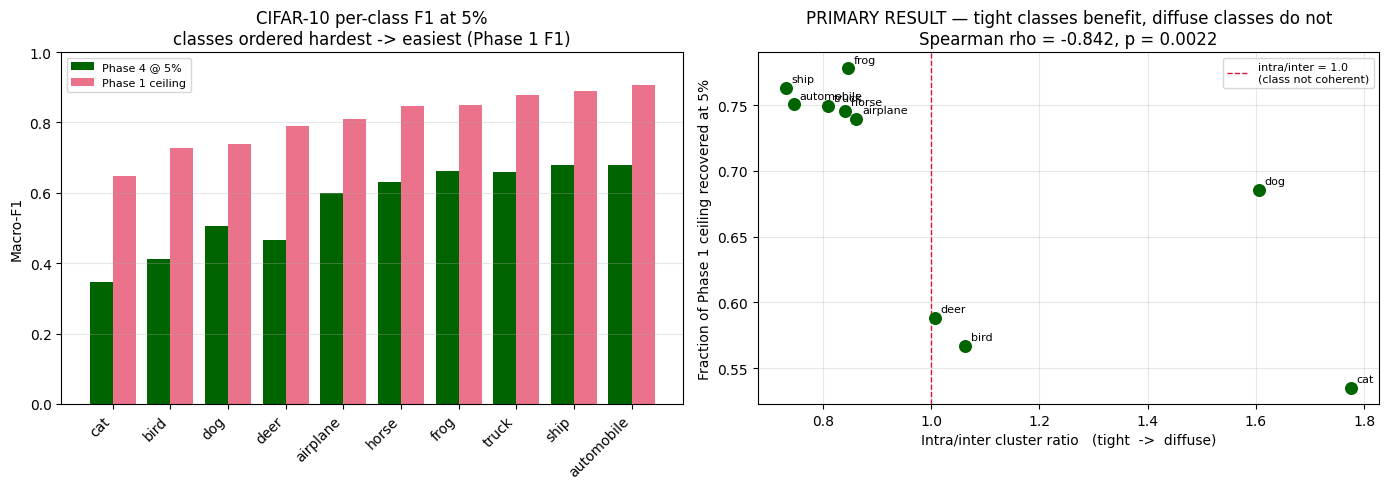

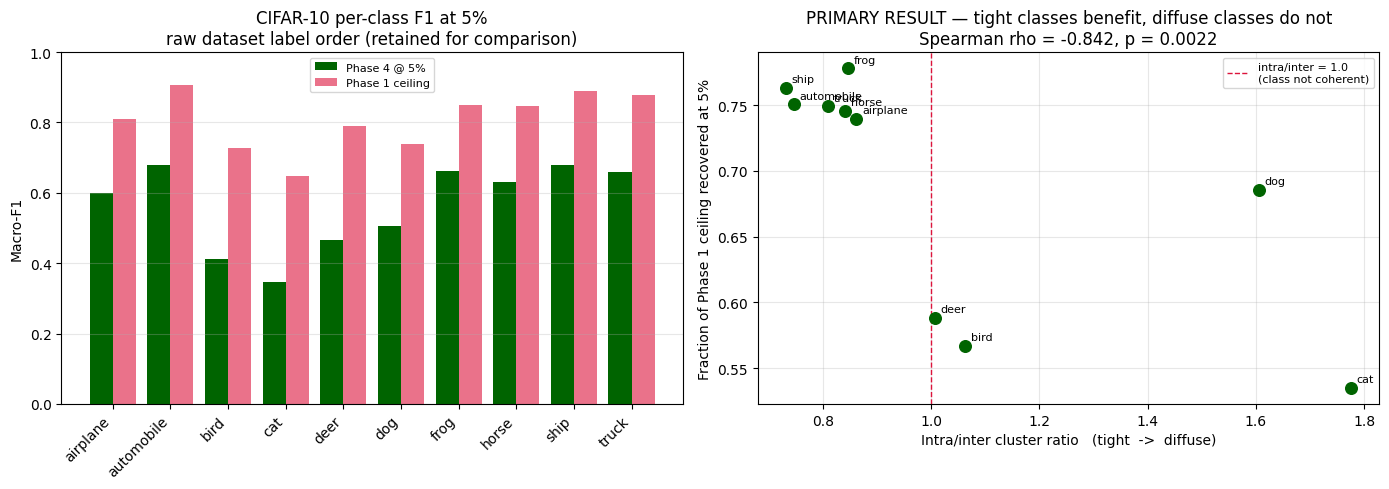

Pre-committed prediction: recovery DECREASES as intra/inter increases (negative rho).
Observed: rho = -0.842, p = 0.0022  -->  CONFIRMED

Canonical class ordering (every figure): cat, bird, dog, deer, airplane, horse, frog, truck, ship, automobile


In [28]:
summ_c    = SUMMARY['CIFAR10']['5%']
p4_f1     = np.array(summ_c['per_class_f1_mean'])
p1_f1     = np.array([P1_PER_CLASS_F1['cifar'][c] for c in CIFAR_CLASSES])
tightness = np.array([RATIO_C[c] for c in CIFAR_CLASSES])   # intra/inter; lower = tighter
recovery  = p4_f1 / p1_f1                                   # fraction of ceiling reached

# The statistic is computed on the raw arrays — class ordering affects presentation only.
rho_mech, p_mech = spearmanr(tightness, recovery)


def plot_mechanism(order_idx, order_tag, title_suffix):
    """Draw the two-panel mechanism figure under a given class ordering."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = [CIFAR_CLASSES[i] for i in order_idx]
    xb    = np.arange(10)

    # Left: per-class F1 against the Phase 1 ceiling, categorical axis sorted low -> high.
    axes[0].bar(xb - 0.2, p4_f1[order_idx], width=0.4, label='Phase 4 @ 5%', color='darkgreen')
    axes[0].bar(xb + 0.2, p1_f1[order_idx], width=0.4, label='Phase 1 ceiling',
                color='crimson', alpha=0.6)
    axes[0].set_xticks(xb); axes[0].set_xticklabels(names, rotation=45, ha='right')
    axes[0].set_ylabel('Macro-F1'); axes[0].set_ylim(0, 1)
    axes[0].set_title(f'CIFAR-10 per-class F1 at 5%\n{title_suffix}')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis='y')

    # Right: the mechanism. x is NUMERIC, so it is inherently ordered tight -> diffuse.
    axes[1].scatter(tightness, recovery, s=70, color='darkgreen', zorder=3)
    for i, c in enumerate(CIFAR_CLASSES):
        axes[1].annotate(c, (tightness[i], recovery[i]), fontsize=8,
                         xytext=(4, 4), textcoords='offset points')
    axes[1].axvline(1.0, color='crimson', linestyle='--', linewidth=1,
                    label='intra/inter = 1.0\n(class not coherent)')
    axes[1].set_xlabel('Intra/inter cluster ratio   (tight  ->  diffuse)')
    axes[1].set_ylabel('Fraction of Phase 1 ceiling recovered at 5%')
    axes[1].set_title(f'PRIMARY RESULT — tight classes benefit, diffuse classes do not\n'
                      f'Spearman rho = {rho_mech:+.3f}, p = {p_mech:.4f}')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/phase4_mechanism{order_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Default: canonical ordering (hardest -> easiest by Phase 1 F1).
plot_mechanism(CLASS_ORDER_IDX['cifar'], '',
               'classes ordered hardest -> easiest (Phase 1 F1)')

# Retained for comparison: raw dataset label order.
plot_mechanism(list(range(10)), '_labelorder',
               'raw dataset label order (retained for comparison)')

verdict = 'CONFIRMED' if (rho_mech < 0 and p_mech < 0.05) else 'NOT CONFIRMED'
print(f'Pre-committed prediction: recovery DECREASES as intra/inter increases (negative rho).')
print(f'Observed: rho = {rho_mech:+.3f}, p = {p_mech:.4f}  -->  {verdict}')
print(f"\nCanonical class ordering (every figure): {', '.join(CLASS_ORDER['cifar'])}")

In [31]:
json.dump(manifest, open(f'{RESULTS_DIR}/phase4_manifest.json', 'w'), indent=2, default=str)
print(f'Manifest saved -> {RESULTS_DIR}/phase4_manifest.json\n')
print('Artefacts:')
for d, tag in [(RESULTS_DIR, 'results'), (FIGURES_DIR, 'figures'),
               (CHECKPOINT_DIR, 'checkpoints'), (INDEX_CACHE, 'indices')]:
    print(f'  {tag:<12}{len(os.listdir(d)):>4} files  {d}')

Manifest saved -> /kaggle/working/results/phase4_manifest.json

Artefacts:
  results        3 files  /kaggle/working/results
  figures        8 files  /kaggle/working/figures
  checkpoints   50 files  /kaggle/working/checkpoints
  indices       50 files  /kaggle/working/phase4_cache/indices
